# Quasi-regular grids construction for quantum dynamics calculations

In this simple tutorial, we demonstrate how to construct quasi-regular grids that could be used in quantum dynamics calculations.

## Table of contents
<a name="toc"></a>
   

### A. Learning objectives

* To construct quasi-regular grids


### B. Use cases

* construct non-uniform grids


### C. Functions

- `libra_py`
  - `grids`
    - [`construct_grid_qrg_fast`](#construct_grid_qrg_fast-1)


In [1]:
import torch
from libra_py import grids

<a name="construct_grid_qrg_fast-1"></a>

In [2]:
help(grids.construct_grid_qrg_fast)

Help on function construct_grid_qrg_fast in module libra_py.grids:

construct_grid_qrg_fast(N_MC, rg, V_, P, rrange1, device='cpu', step=0.01)
    Optimize a quantum reference grid (QRG) using Monte Carlo sampling.
    
    This routine performs a stochastic optimization of grid points by
    minimizing the total pairwise repulsive energy between them.
    The algorithm is equivalent to the Fortran routine `Construct_grid_QRG`.
    
    The optimization proceeds by repeatedly proposing random displacements
    of individual grid points and accepting only energy-lowering moves
    (zero-temperature Monte Carlo).
    
    Parameters
    ----------
    N_MC : int
        Number of Monte Carlo sweeps per grid point.
        Total number of trial moves = NG * N_MC.
    
    rg : torch.Tensor, shape (d1, NG)
        Coordinates of grid points.
    
    V_ : torch.Tensor, shape (NG,)
        Potential energy at each grid point.
    
    P : callable
        Function evaluating the probability

In [3]:
d1 = 2
NG = 25

rg = torch.randn(d1, NG)
V_ = torch.zeros(NG)
rrange1 = torch.ones(d1)

def P(r):
    V = 0.025*torch.sum(r**2)
    Pval = torch.exp(-V)
    return Pval, V

rg_opt, sigma, V = grids.construct_grid_qrg_fast(
    N_MC=500,
    rg=rg,
    V_=V_,
    P=P,
    rrange1=rrange1,
    device="cpu",
    step=0.1
)

Start optimizing QRG
Step 250 | step_size = 0.1000 | energy = 1786.4745
Step 500 | step_size = 0.0900 | energy = 2490.8552
Step 750 | step_size = 0.0900 | energy = 263.2376
Step 1000 | step_size = 0.0810 | energy = 2.9928
Step 1250 | step_size = 0.0729 | energy = 208.5519
Step 1500 | step_size = 0.0656 | energy = 60.2800
Step 1750 | step_size = 0.0590 | energy = 11.4691
Step 2000 | step_size = 0.0590 | energy = 11.9466
Step 2250 | step_size = 0.0590 | energy = 0.1181
Step 2500 | step_size = 0.0531 | energy = 4.4788
Step 2750 | step_size = 0.0531 | energy = 1.4232
Step 3000 | step_size = 0.0478 | energy = 3.8151
Step 3250 | step_size = 0.0430 | energy = 0.9494
Step 3500 | step_size = 0.0387 | energy = 0.6761
Step 3750 | step_size = 0.0349 | energy = 0.3902
Step 4000 | step_size = 0.0349 | energy = 0.7998
Step 4250 | step_size = 0.0314 | energy = 0.1621
Step 4500 | step_size = 0.0314 | energy = 0.2303
Step 4750 | step_size = 0.0282 | energy = 0.0949
Step 5000 | step_size = 0.0282 | energ

In [4]:
print(rg_opt.shape)
print(rg_opt)

torch.Size([2, 25])
tensor([[-2.8346e+00, -1.7253e+00, -2.9515e+00, -3.5002e-01,  1.1383e+00,
         -4.3965e+00, -1.0301e+00,  5.5052e+00, -9.4440e-01,  5.0221e+00,
          1.6317e+00,  6.2642e-01, -4.0537e+00, -6.8896e-01, -1.1328e+00,
         -2.2485e+00,  9.6248e-01,  2.9419e+00,  3.2138e+00,  1.1796e+00,
          5.0124e-03, -3.1034e+00,  3.3028e+00,  2.9207e+00,  1.3492e+00],
        [-3.6781e+00,  1.5971e-01,  1.5820e+00, -1.0187e+00, -4.2554e+00,
         -2.0559e+00,  3.9011e+00,  4.0667e-01, -4.9272e+00, -2.0084e+00,
          1.3650e+00,  2.8071e+00,  2.8529e-02, -2.7941e+00,  1.9733e+00,
         -1.5812e+00,  4.9713e+00,  3.0019e+00, -3.5581e+00, -2.2033e+00,
          6.9295e-01,  3.5968e+00,  6.8549e-01, -1.2963e+00, -3.8555e-01]])


In [5]:
import matplotlib.pyplot as plt

def plot_grid_2d(rg):
    """
    Plot 2D grid points.
    
    Parameters
    ----------
    rg : torch.Tensor (d1, NG)
    """

    coords = rg.T.cpu().numpy()

    plt.figure(figsize=(6,6))
    plt.scatter(coords[:,0], coords[:,1], s=20)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("QRG grid")
    plt.axis("equal")
    plt.show()

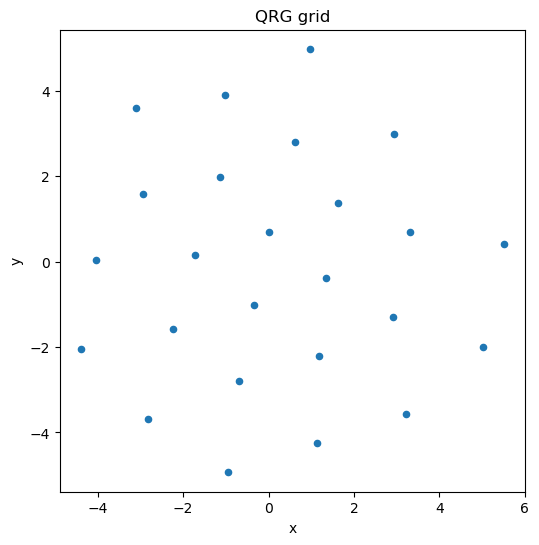

In [6]:
plot_grid_2d(rg_opt)